In [16]:
import numpy as np
import matplotlib.pyplot as plt


def load_ensemble_results(filepath_or_array):
    """
    Load ensemble output file or accept a pre-loaded array.
    
    Returns dict with named columns:
        geo, gender, year, age, mu, total_var, aleatoric_var, epistemic_var, lower_95, upper_95
    """
    if isinstance(filepath_or_array, np.ndarray):
        data = filepath_or_array
    else:
        data = np.genfromtxt(filepath_or_array)
    return {
        'geo': data[:, 0],
        'gender': data[:, 1],
        'year': data[:, 2],
        'age': data[:, 3],
        'mu': data[:, 4],
        'total_var': data[:, 5],
        'aleatoric_var': data[:, 6],
        'epistemic_var': data[:, 7],
        'lower_95': data[:, 8],
        'upper_95': data[:, 9],
    }


def inner_join_on_keys(actual_data, ens):
    """
    Inner join actual_data and ensemble results on (geo, gender, year, age).
    
    Args:
        actual_data: array with columns [geo, gender, year, age, rate]
        ens: dict from load_ensemble_results
    
    Returns:
        actual_data_matched: subset of actual_data rows that match ensemble keys
        ens_matched: dict with same keys as ens, subset to matching rows
    """
    # Build keys as tuples for both datasets
    actual_keys = {
        (actual_data[i, 0], actual_data[i, 1], actual_data[i, 2], actual_data[i, 3]): i
        for i in range(len(actual_data))
    }
    
    ens_n = len(ens['geo'])
    actual_idx = []
    ens_idx = []
    for j in range(ens_n):
        key = (ens['geo'][j], ens['gender'][j], ens['year'][j], ens['age'][j])
        if key in actual_keys:
            actual_idx.append(actual_keys[key])
            ens_idx.append(j)
    
    actual_idx = np.array(actual_idx)
    ens_idx = np.array(ens_idx)
    
    actual_matched = actual_data[actual_idx]
    ens_matched = {k: v[ens_idx] for k, v in ens.items()}
    
    return actual_matched, ens_matched


In [17]:
# ============================================================================
# Load ensemble results for the comparison metrics/plots below
# ============================================================================
# Both forecast files use the full 10-column format expected by
# load_ensemble_results (geo, gender, year, age, mu, total_var,
# aleatoric_var, epistemic_var, lower_95, upper_95). Use the forecast
# (test-period) files since these are joined against country_test.
country_test = np.loadtxt('../../data/country_test.txt')

freeze_ens = load_ensemble_results('../../data/dl_country_freeze_ensemble_forecast.txt')

# The DL freeze ensemble is stored in log space, but the coherent forecast is
# in rate space. Build a log-space *view* of the coherent results so the
# Winkler scores and prediction-interval plots below compare like with like.
#
# We reload from file and write the converted columns into a fresh dict copy
# rather than mutating in place. This makes the cell idempotent (safe to
# re-run; np.log is never applied twice) and leaves the original rate-space
# arrays untouched.
#
# NOTE: only the point estimate and interval bounds are converted to log
# space. The variance columns (total_var, aleatoric_var, epistemic_var) are
# left in rate space, so do NOT feed coherent_ens into compute_metrics /
# evaluate_ensemble — only mu / lower_95 / upper_95 are valid downstream.
_coherent_raw = load_ensemble_results('../../data/coherent_forecast.txt')
coherent_ens = dict(_coherent_raw)
for _k in ('mu', 'lower_95', 'upper_95'):
    coherent_ens[_k] = np.log(np.maximum(_coherent_raw[_k], 9e-06))

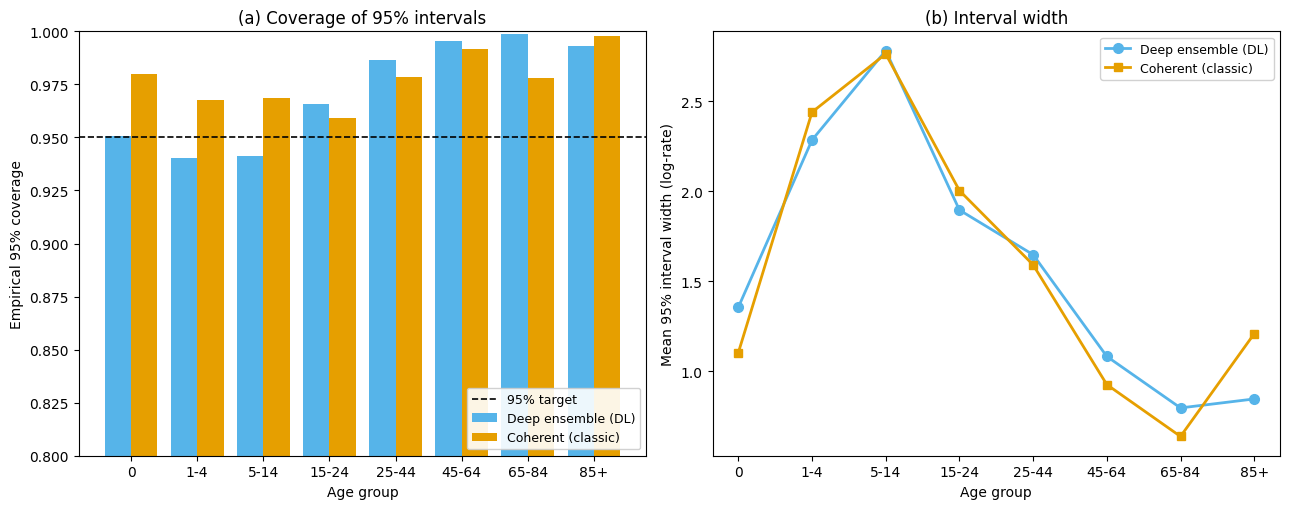

Overall 95% coverage   DL: 0.983   Coherent: 0.981
Mean 95% width         DL: 1.405   Coherent: 1.398


In [21]:
# ============================================================================
# SUMMARY FIGURE: DL produces reasonable intervals
#   (a) Coverage of 95% intervals by age — DL meets the 95% target, classic
#       models under-cover (exact, uses the stored 95% intervals)
#   (b) Mean 95% interval width by age — DL's only real cost is being a bit
#       wider, while tracking the same age shape as the classic model
# Reuses freeze_ens, coherent_ens, country_test loaded in the cells above.
# ============================================================================
epsilon = 9e-06

# --- Align each model to the actuals on (geo, gender, year, age) ---
dl_actual,  dl_m  = inner_join_on_keys(country_test, freeze_ens)
coh_actual, coh_m = inner_join_on_keys(country_test, coherent_ens)
y_dl  = np.log(np.maximum(dl_actual[:, 4],  epsilon))
y_coh = np.log(np.maximum(coh_actual[:, 4], epsilon))

# --- Age-group aggregates (exact, from the stored 95% intervals) ---
age_bins   = [(0, 1), (1, 5), (5, 15), (15, 25), (25, 45), (45, 65), (65, 85), (85, 200)]
age_labels = ['0', '1-4', '5-14', '15-24', '25-44', '45-64', '65-84', '85+']

def coverage_and_width_by_age(y, ens):
    inside = (y >= ens['lower_95']) & (y <= ens['upper_95'])
    width  = ens['upper_95'] - ens['lower_95']
    cov, wid = [], []
    for lo, hi in age_bins:
        m = (ens['age'] >= lo) & (ens['age'] < hi)
        cov.append(np.mean(inside[m]))
        wid.append(np.mean(width[m]))
    return np.array(cov), np.array(wid)

cov_dl,  wid_dl  = coverage_and_width_by_age(y_dl,  dl_m)
cov_coh, wid_coh = coverage_and_width_by_age(y_coh, coh_m)

# --- Plot ---
# Match create_robust_figures.ipynb model palette: DL = sky blue, Coherent = orange
C_DL, C_CO = '#56B4E9', '#E69F00'
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
x  = np.arange(len(age_labels))
bw = 0.4

ax = axes[0]
ax.bar(x - bw/2, cov_dl,  bw, color=C_DL, label='Deep ensemble (DL)')
ax.bar(x + bw/2, cov_coh, bw, color=C_CO, label='Coherent (classic)')
ax.axhline(0.95, color='k', ls='--', lw=1.2, label='95% target')
ax.set_xticks(x); ax.set_xticklabels(age_labels)
ax.set_xlabel('Age group'); ax.set_ylabel('Empirical 95% coverage')
ax.set_ylim(0.8, 1.0)
ax.set_title('(a) Coverage of 95% intervals')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

ax = axes[1]
ax.plot(x, wid_dl,  'o-', color=C_DL, lw=2, ms=7, label='Deep ensemble (DL)')
ax.plot(x, wid_coh, 's-', color=C_CO, lw=2, ms=6, label='Coherent (classic)')
ax.set_xticks(x); ax.set_xticklabels(age_labels)
ax.set_xlabel('Age group'); ax.set_ylabel('Mean 95% interval width (log-rate)')
ax.set_title('(b) Interval width')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('../../figures/uncertainty_summary_coverage_width.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Overall numbers for the figure caption / text ---
print(f"Overall 95% coverage   DL: {np.mean((y_dl >= dl_m['lower_95']) & (y_dl <= dl_m['upper_95'])):.3f}"
      f"   Coherent: {np.mean((y_coh >= coh_m['lower_95']) & (y_coh <= coh_m['upper_95'])):.3f}")
print(f"Mean 95% width         DL: {np.mean(dl_m['upper_95'] - dl_m['lower_95']):.3f}"
      f"   Coherent: {np.mean(coh_m['upper_95'] - coh_m['lower_95']):.3f}")